<a href="https://colab.research.google.com/github/SujalGodse/Advance-Analytics-using-Statistics/blob/main/Advance_Analytics_using_Statistics_Day20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random Forest**

In [1]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression


import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

from statsmodels.discrete.discrete_model import MNLogit

from sklearn.tree import DecisionTreeClassifier

import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest

from scipy.stats import chisquare

from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson

from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

In [5]:
df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx', sheet_name = 'diabetes')
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]

diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df = df.drop('DietType', axis=1)
df = pd.concat([df,diet_dummy], axis=1)

x= df.drop('Outcome', axis=1)  # column of predictors
y= df.Outcome   # column of response

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)


In [6]:
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

y_pred=dtc.predict(x_test)

In [7]:
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

[[85 16]
 [17 36]]
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       101
           1       0.69      0.68      0.69        53

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.79      0.79       154

1.0
0.7857142857142857


In [8]:
# hyperparameter tuning

param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [2,3,4,5]
}

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 7,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'splitter': 'random'}

In [9]:
dtc = DecisionTreeClassifier(criterion= 'gini',
 max_depth= 5,
 max_features= 'sqrt',
 min_samples_leaf= 5,
 min_samples_split= 2,
 splitter= 'best')

dtc.fit(x_train,y_train)
print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

y_pred = dtc.predict(x_test)
print(confusion_matrix(y_test,y_pred))

0.8827361563517915
0.8571428571428571
[[94  7]
 [15 38]]


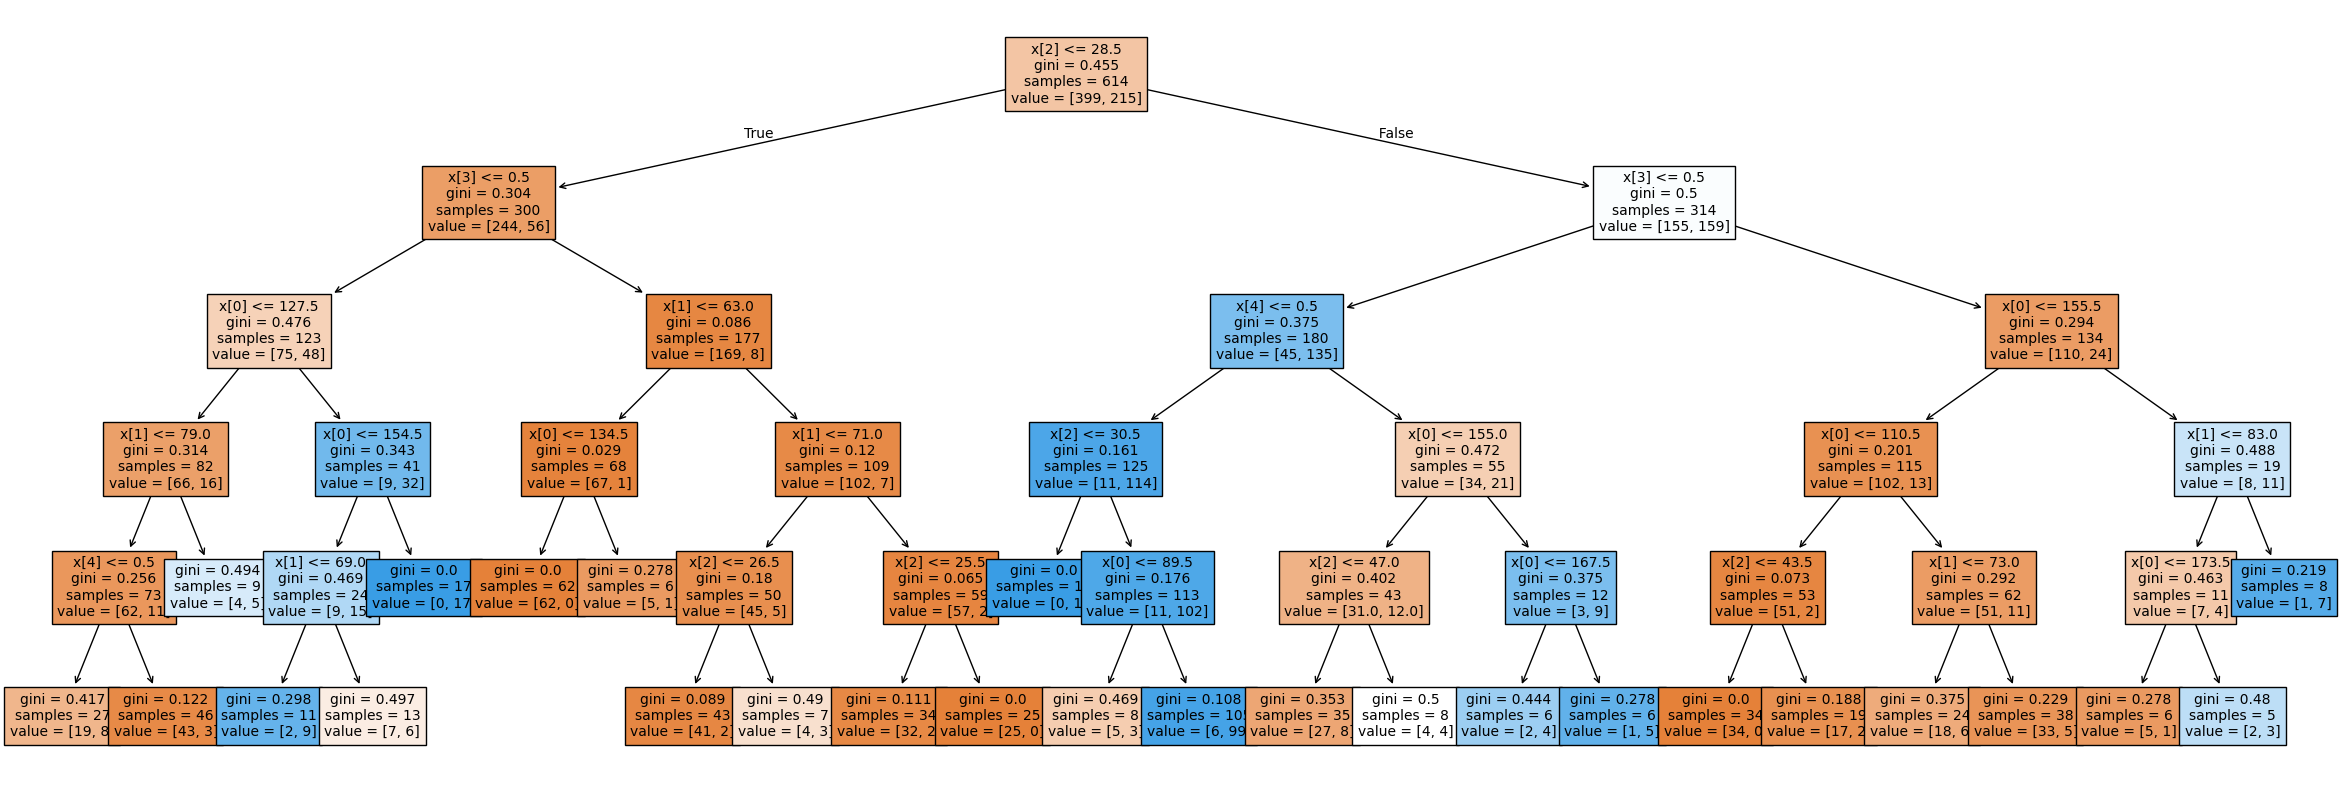

In [16]:
from sklearn import tree
plt.figure(figsize=(30,10))
tree.plot_tree(dtc,filled=True,fontsize=10)
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=50,max_depth=4)
rfc.fit(x_train,y_train)
print(rfc.score(x_train, y_train))   # training data accuracy
print(rfc.score(x_test, y_test))    # test data accuracy

0.8957654723127035
0.8831168831168831


Random Forest Parameters : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

## **Boosting**

for boosting refer excel sheet : /content/drive/MyDrive/CDAC/BoostingModels.xlsx